# deterministic algorithm Implementation

In [1]:
from typing import List, Tuple

def partition_3way(arr: List[int], low: int, high: int, pivot: int) -> Tuple[int, int]:
    """
    3-Way Dutch National Flag Partitioning around a given pivot value.
    
    Rearranges arr[low..high] into three sections:
      - arr[low .. lt - 1]  < pivot
      - arr[lt .. gt]       == pivot
      - arr[gt + 1 .. high] > pivot
      
    Returns:
      Tuple (lt, gt) representing the start and end indices of the equal-to-pivot range.
    """
    
    i = low
    lt = low
    gt = high
    
    while i <= gt:
        if arr[i] < pivot:
            arr[lt], arr[i] = arr[i], arr[lt]
            lt += 1
            i += 1
        elif arr[i] > pivot:
            arr[gt], arr[i] = arr[i], arr[gt]
            gt -= 1
        else:
            i += 1
            
    return lt, gt


def _get_pivot_mom(arr: List[int], low: int, high: int) -> int:
    
    """
    Computes the Median of Medians pivot deterministically for arr[low..high].
    """
    n = high - low + 1
    
    # Base case: For 5 or fewer elements, sort directly and take the median
    if n <= 5:
        sub = sorted(arr[low:high + 1])
        return sub[n // 2]
    
    # Dividing subarray into blocks of 5 and find each group's median
    medians = []
    for i in range(low, high + 1, 5):
        group_high = min(i + 4, high)
        group = sorted(arr[i:group_high + 1])
        medians.append(group[len(group) // 2])
        
    # Recursively find the median of the extracted medians
    return _mom_select_helper(medians, 0, len(medians) - 1, len(medians) // 2)


def _mom_select_helper(arr: List[int], low: int, high: int, k: int) -> int:
    """
    Recursive helper function to find the k-th smallest element (0-indexed).
    """
    if low == high:
        return arr[low]
    
    # 1. Deterministically selecting the pivot using Median of Medians
    pivot = _get_pivot_mom(arr, low, high)
    
    # 2. Partitioning using 3-way Dutch National Flag
    lt, gt = partition_3way(arr, low, high, pivot)
    
    # 3. Recursing into the appropriate partition based on rank target k
    if k < lt:
        return _mom_select_helper(arr, low, lt - 1, k)
    elif k > gt:
        return _mom_select_helper(arr, gt + 1, high, k)
    else:
        # k lies within the range of elements equal to the pivot
        return arr[k]


def deterministic_select(arr: List[int], k: int) -> int:
    """
    Public API function: Returns the k-th smallest element (0-indexed) 
    in worst-case O(n) time.
    """
    if not 0 <= k < len(arr):
        raise IndexError(f"Rank k={k} is out of bounds for array of length {len(arr)}.")
    
    # Operate on a copy to avoid mutating the original input array
    arr_copy = list(arr)
    return _mom_select_helper(arr_copy, 0, len(arr_copy) - 1, k)

# Validation

In [2]:
def test_deterministic_select():
    # Test 1: Standard unsorted array
    data1 = [12, 3, 5, 7, 4, 19, 26]
    assert deterministic_select(data1, 0) == 3   # Minimum
    assert deterministic_select(data1, 3) == 7   # Median
    assert deterministic_select(data1, 6) == 26  # Maximum

    # Test 2: Heavy duplicates
    data2 = [5, 2, 5, 5, 1, 2, 9, 5, 5]
    sorted_data2 = sorted(data2)
    for k in range(len(data2)):
        assert deterministic_select(data2, k) == sorted_data2[k]

    # Test 3: Large array
    import random
    data3 = [random.randint(-10000, 10000) for _ in range(500)]
    sorted_data3 = sorted(data3)
    for k in [0, 100, 250, 499]:
        assert deterministic_select(data3, k) == sorted_data3[k]

    print("All unit tests passed for Deterministic Selection!")

test_deterministic_select()

All unit tests passed for Deterministic Selection!


# Summary 

Pivot Strategy: Calculates a guaranteed well-balanced pivot by dividing the array into groups of 5 elements, sorting each small group to find its median, and recursively finding the median of that group:
	
    medians.Core Logic: Uses this guaranteed pivot to partition the array via 3-way Dutch National Flag partitioning (< pivot, == pivot, > pivot), ensuring at least 30%of the elements are discarded in every recursive step.
    
	Guarantees & Performance: Eliminates worst-case performance risks, strictly guaranteeing worst-case O(n) time complexity regardless of the initial ordering or pattern of the input array.
    
	Edge-Case Handling: The 3-way partitioning prevents infinite recursion on arrays with high frequencies of identical elements by isolating all equal keys in a single step.


# randomized  algorithm Implementation

In [3]:
import random
from typing import List, Tuple

def partition_3way(arr: List[int], low: int, high: int, pivot: int) -> Tuple[int, int]:
    """
    3-Way Dutch National Flag Partitioning around a given pivot value.
    
    Rearranges arr[low..high] into three sections:
      - arr[low .. lt - 1]  < pivot
      - arr[lt .. gt]       == pivot
      - arr[gt + 1 .. high] > pivot
      
    Returns:
      Tuple (lt, gt) representing the start and end indices of the equal-to-pivot range.
    """
    i = low
    lt = low
    gt = high
    
    while i <= gt:
        if arr[i] < pivot:
            arr[lt], arr[i] = arr[i], arr[lt]
            lt += 1
            i += 1
        elif arr[i] > pivot:
            arr[gt], arr[i] = arr[i], arr[gt]
            gt -= 1
        else:
            i += 1
            
    return lt, gt


def _randomized_select_helper(arr: List[int], low: int, high: int, k: int) -> int:
    """
    Recursive helper function to find the k-th smallest element (0-indexed)
    in expected linear time using random pivot selection.
    """
    if low == high:
        return arr[low]
    
    # 1. Choose a pivot uniformly at random from arr[low..high]
    pivot_idx = random.randint(low, high)
    pivot = arr[pivot_idx]
    
    # 2. Partition array using 3-way Dutch National Flag
    lt, gt = partition_3way(arr, low, high, pivot)
    
    # 3. Recurse into the relevant partition based on target rank k
    if k < lt:
        return _randomized_select_helper(arr, low, lt - 1, k)
    elif k > gt:
        return _randomized_select_helper(arr, gt + 1, high, k)
    else:
        # k lies within the range of elements equal to the pivot
        return arr[k]


def randomized_select(arr: List[int], k: int) -> int:
    """
    Public API function: Returns the k-th smallest element (0-indexed) 
    in expected O(n) time.
    """
    if not 0 <= k < len(arr):
        raise IndexError(f"Rank k={k} is out of bounds for array of length {len(arr)}.")
    
    # Operate on a copy to avoid mutating the original input array
    arr_copy = list(arr)
    return _randomized_select_helper(arr_copy, 0, len(arr_copy) - 1, k)

# Validation

In [4]:
def test_randomized_select():
    # Test 1: Standard unsorted array
    data1 = [12, 3, 5, 7, 4, 19, 26]
    assert randomized_select(data1, 0) == 3   # Minimum
    assert randomized_select(data1, 3) == 7   # Median
    assert randomized_select(data1, 6) == 26  # Maximum

    # Test 2: Pre-sorted array (tests immunity to sorted worst-case traps)
    data2 = list(range(100))
    assert randomized_select(data2, 49) == 49

    # Test 3: Heavy duplicate elements
    data3 = [7, 7, 1, 7, 3, 7, 7, 2, 7]
    sorted_data3 = sorted(data3)
    for k in range(len(data3)):
        assert randomized_select(data3, k) == sorted_data3[k]

    print("All unit tests passed for Randomized Selection!")

test_randomized_select()

All unit tests passed for Randomized Selection!


# Summary

•	Pivot Strategy: Selects a pivot element uniformly at random from the current subarray range [lowhigh] O(n) time complexity with exceptionally low constant-factor overhead, though it retains a theoretical worst-case runtime of O(n^2) if extreme pivots are repeatedly chosen. 

•	Edge-Case Handling: Random pivot selection naturally breaks sensitivity to sorted or reverse-sorted array layouts, while 3-way partitioning efficiently collapses identical keys to prevent degradation on duplicate-heavy inputs.


# Empirical Analysis

EMPIRICAL BENCHMARK: RANDOMIZED VS. DETERMINISTIC SELECTION

--- Distribution: Random ---
Size (N)   | Randomized (ms)    | Deterministic (ms) | Overhead Factor 
------------------------------------------------------------------------
1000       | 0.531              | 0.815              | 1.54            x
5000       | 2.704              | 3.897              | 1.44            x
10000      | 3.702              | 5.259              | 1.42            x
50000      | 15.895             | 28.973             | 1.82            x
100000     | 46.334             | 58.509             | 1.26            x
200000     | 62.952             | 116.663            | 1.85            x


--- Distribution: Sorted ---
Size (N)   | Randomized (ms)    | Deterministic (ms) | Overhead Factor 
------------------------------------------------------------------------
1000       | 0.379              | 0.518              | 1.37            x
5000       | 1.794              | 2.608              | 1.45            x
10000

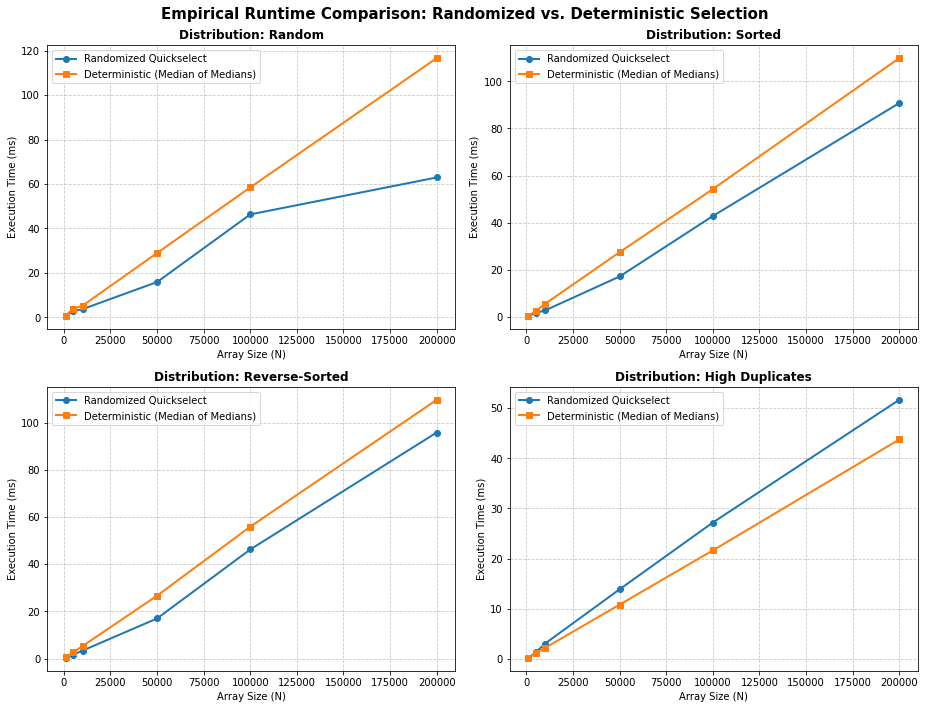

In [8]:
import sys
import time
import random
from typing import List, Tuple, Dict

# Increase recursion depth for large array benchmarks
sys.setrecursionlimit(200000)

# Try importing matplotlib for report plot generation
try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False


# 1. CORE ALGORITHMS

def partition_3way(arr: List[int], low: int, high: int, pivot: int) -> Tuple[int, int]:
    i = low
    lt = low
    gt = high
    while i <= gt:
        if arr[i] < pivot:
            arr[lt], arr[i] = arr[i], arr[lt]
            lt += 1
            i += 1
        elif arr[i] > pivot:
            arr[gt], arr[i] = arr[i], arr[gt]
            gt -= 1
        else:
            i += 1
    return lt, gt


# --- Randomized Selection ---
def randomized_select(arr: List[int], k: int) -> int:
    arr_copy = list(arr)
    return _randomized_select_helper(arr_copy, 0, len(arr_copy) - 1, k)

def _randomized_select_helper(arr: List[int], low: int, high: int, k: int) -> int:
    if low == high:
        return arr[low]
    pivot_idx = random.randint(low, high)
    pivot = arr[pivot_idx]
    lt, gt = partition_3way(arr, low, high, pivot)
    if k < lt:
        return _randomized_select_helper(arr, low, lt - 1, k)
    elif k > gt:
        return _randomized_select_helper(arr, gt + 1, high, k)
    else:
        return arr[k]

# --- Deterministic Selection (Median of Medians) ---
def median_of_medians_select(arr: List[int], k: int) -> int:
    arr_copy = list(arr)
    return _mom_select_helper(arr_copy, 0, len(arr_copy) - 1, k)

def _get_pivot_mom(arr: List[int], low: int, high: int) -> int:
    n = high - low + 1
    if n <= 5:
        sub = sorted(arr[low : high + 1])
        return sub[n // 2]
    medians = []
    for i in range(low, high + 1, 5):
        group_high = min(i + 4, high)
        group = sorted(arr[i : group_high + 1])
        medians.append(group[len(group) // 2])
    return _mom_select_helper(medians, 0, len(medians) - 1, len(medians) // 2)

def _mom_select_helper(arr: List[int], low: int, high: int, k: int) -> int:
    if low == high:
        return arr[low]
    pivot = _get_pivot_mom(arr, low, high)
    lt, gt = partition_3way(arr, low, high, pivot)
    if k < lt:
        return _mom_select_helper(arr, low, lt - 1, k)
    elif k > gt:
        return _mom_select_helper(arr, gt + 1, high, k)
    else:
        return arr[k]


# 2. DATA GENERATORS & BENCHMARK SUITE

def generate_data(size: int, distribution: str) -> List[int]:
    """Generates test inputs for specified distributions."""
    if distribution == "Random":
        return [random.randint(0, size * 10) for _ in range(size)]
    elif distribution == "Sorted":
        return list(range(size))
    elif distribution == "Reverse-Sorted":
        return list(range(size, 0, -1))
    elif distribution == "High Duplicates":
        return [random.randint(0, 10) for _ in range(size)]
    else:
        raise ValueError(f"Unknown distribution: {distribution}")


def run_benchmarks():
    sizes = [1000, 5000, 10000, 50000, 100000, 200000]
    distributions = ["Random", "Sorted", "Reverse-Sorted", "High Duplicates"]
    trials = 5  # Average timing across 5 runs

    results: Dict[str, Dict[str, List[float]]] = {
        dist: {"Randomized": [], "Deterministic": []} for dist in distributions
    }

    print("=" * 80)
    print("EMPIRICAL BENCHMARK: RANDOMIZED VS. DETERMINISTIC SELECTION")
    print("=" * 80 + "\n")

    for dist in distributions:
        print(f"--- Distribution: {dist} ---")
        print(
            f"{'Size (N)':<10} | {'Randomized (ms)':<18} | {'Deterministic (ms)':<18} | {'Overhead Factor':<16}"
        )
        print("-" * 72)

        for size in sizes:
            rand_times = []
            mom_times = []
            k = size // 2  # Find median index

            for _ in range(trials):
                data = generate_data(size, dist)

                # Measure Randomized Quickselect
                t0 = time.perf_counter()
                res_rand = randomized_select(data, k)
                t_rand = (time.perf_counter() - t0) * 1000
                rand_times.append(t_rand)

                # Measure Deterministic Median of Medians
                t0 = time.perf_counter()
                res_mom = median_of_medians_select(data, k)
                t_mom = (time.perf_counter() - t0) * 1000
                mom_times.append(t_mom)

                # Sanity check
                assert res_rand == res_mom, "Mismatch between selection outputs!"

            avg_rand = sum(rand_times) / trials
            avg_mom = sum(mom_times) / trials
            factor = avg_mom / avg_rand if avg_rand > 0 else 0.0

            results[dist]["Randomized"].append(avg_rand)
            results[dist]["Deterministic"].append(avg_mom)

            print(
                f"{size:<10} | {avg_rand:<18.3f} | {avg_mom:<18.3f} | {factor:<16.2f}x"
            )
        print("\n")

    # Generate Matplotlib plots for report write-up
    if HAS_MATPLOTLIB:
        fig, axes = plt.subplots(2, 2, figsize=(13, 10))
        fig.suptitle(
            "Empirical Runtime Comparison: Randomized vs. Deterministic Selection",
            fontsize=15,
            fontweight="bold",
        )

        positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
        for idx, dist in enumerate(distributions):
            ax = axes[positions[idx]]
            ax.plot(
                sizes,
                results[dist]["Randomized"],
                marker="o",
                linewidth=2,
                label="Randomized Quickselect",
            )
            ax.plot(
                sizes,
                results[dist]["Deterministic"],
                marker="s",
                linewidth=2,
                label="Deterministic (Median of Medians)",
            )
            ax.set_title(f"Distribution: {dist}", fontsize=12, fontweight="bold")
            ax.set_xlabel("Array Size (N)")
            ax.set_ylabel("Execution Time (ms)")
            ax.legend()
            ax.grid(True, linestyle="--", alpha=0.7)

        plt.tight_layout()
        
        print("Plots generated successfully'.")
    else:
        raise e

if __name__ == "__main__":
    run_benchmarks()